퇴근 현재 137.3460784255867
퇴근 PSO 96.10431601970558
퇴근 개선율 30.02762283323996
출근 현재 70.88182315323564
출근 PSO 63.53084267399268
출근 개선율 10.370755367495661
평시 현재 60.36876257631258
평시 pso 48.485394054402406
평시 개선율 19.684631612066454


C:\Users\user\AppData\Local\Temp\ipykernel_36060\2628270346.py:150: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_36060\2628270346.py:226: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


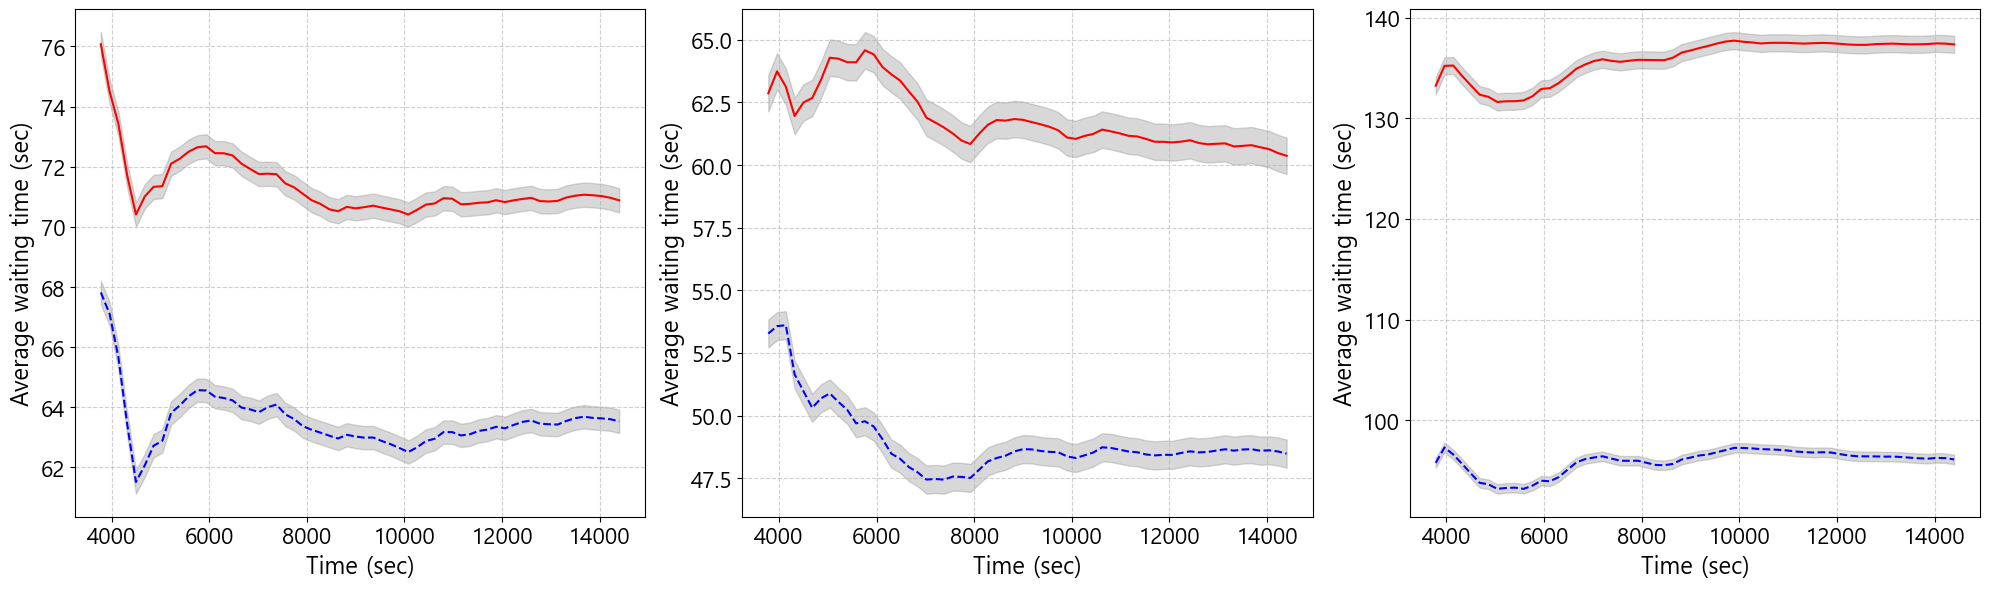

In [174]:
#################################################################################################################################################
# 퇴근
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rc('font', family='Malgun Gothic')

df_current = pd.read_csv('퇴근 신호 시뮬레이션 결과.csv')
df_pso = pd.read_csv('퇴근_PSO_신호 시뮬레이션 결과.csv')

current_datasets = df_current.iloc[:,1:].values.tolist()
pso_datasets = df_pso.iloc[:,1:].values.tolist()

confidence_level = 0.95
n = len(current_datasets[0])
z = 1.96

upper_combined_current = np.zeros(n)
lower_combined_current = np.zeros(n)
upper_combined_pso = np.zeros(n)
lower_combined_pso = np.zeros(n)
x_values = np.linspace(3780, 14400, n)

# Calculate combined confidence intervals for the 'current' datasets
for i in range(n):
    means_current = [dataset[i] for dataset in current_datasets]
    combined_mean_current = [np.mean(dataset) for dataset in current_datasets]
    std_devs_current = [np.std(dataset) for dataset in current_datasets]
    
    margin_errors_current = [z * (std_dev / np.sqrt(n)) for std_dev in std_devs_current]
    
    combined_mean_current = np.mean(means_current)
    combined_margin_error_current = np.sqrt(np.sum([error ** 2 for error in margin_errors_current]) / len(current_datasets))
    
    upper_combined_current[i] = combined_mean_current + combined_margin_error_current
    lower_combined_current[i] = combined_mean_current - combined_margin_error_current
print('퇴근 현재', combined_mean_current)
# Calculate combined confidence intervals for the 'PSO' datasets
for i in range(n):
    means_pso = [dataset[i] for dataset in pso_datasets]
    combined_mean_pso = [np.mean(dataset) for dataset in pso_datasets]
    std_devs_pso = [np.std(dataset) for dataset in pso_datasets]
    
    margin_errors_pso = [z * (std_dev / np.sqrt(n)) for std_dev in std_devs_pso]
    
    # Calculate the combined confidence interval (for the mean of 'PSO' datasets)
    combined_mean_pso = np.mean(means_pso)
    combined_margin_error_pso = np.sqrt(np.sum([error ** 2 for error in margin_errors_pso]) / len(pso_datasets))
    
    upper_combined_pso[i] = combined_mean_pso + combined_margin_error_pso
    lower_combined_pso[i] = combined_mean_pso - combined_margin_error_pso
print('퇴근 PSO', combined_mean_pso)
print('퇴근 개선율', 100-(combined_mean_pso/combined_mean_current*100))
plt.figure(figsize=(20, 6))

# Plot 'current' datasets
# for i, dataset in enumerate(current_datasets):
#     plt.plot(range(n), dataset, label=f'Current Dataset {i + 1}', linestyle='dashed')

# Plot 'PSO' datasets
# for i, dataset in enumerate(pso_datasets):
#     plt.plot(range(n), dataset, label=f'PSO Dataset {i + 1}')
plt.subplot(1,3,3)
plt.plot(np.linspace(3780, 14400, 60), [(np.mean([dataset[i] for dataset in current_datasets])) for i in range(n)], label='기존 신호', color='red')
plt.plot(np.linspace(3780, 14400, 60), [(np.mean([dataset[i] for dataset in pso_datasets])) for i in range(n)], '--', label='제안 신호', color='blue')
plt.fill_between(np.linspace(3780, 14400, 60), lower_combined_current, upper_combined_current, alpha=0.3, color='gray', label='신뢰구간 95%')
plt.fill_between(np.linspace(3780, 14400, 60), lower_combined_pso, upper_combined_pso, alpha=0.3, color='gray')

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
# plt.legend(fontsize=22)
# plt.legend(fontsize=22, loc='upper center', bbox_to_anchor=(0.85, 0.8))
plt.xlabel('Time (sec)', fontsize=17)
plt.ylabel('Average waiting time (sec)', fontsize=17)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

#################################################################################################################################################
# 출근
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rc('font', family='Malgun Gothic')

df_current = pd.read_csv('출근1_신호 시뮬레이션 결과.csv')
df_pso = pd.read_csv('출근_PSO_신호 시뮬레이션 결과.csv')

current_datasets = df_current.iloc[:,1:].values.tolist()
pso_datasets = df_pso.iloc[:,1:].values.tolist()

confidence_level = 0.95
n = len(current_datasets[0])
z = 1.96

upper_combined_current = np.zeros(n)
lower_combined_current = np.zeros(n)
upper_combined_pso = np.zeros(n)
lower_combined_pso = np.zeros(n)
x_values = np.linspace(3780, 14400, n)

# Calculate combined confidence intervals for the 'current' datasets
for i in range(n):
    means_current = [dataset[i] for dataset in current_datasets]
    std_devs_current = [np.std(dataset) for dataset in current_datasets]
    
    margin_errors_current = [z * (std_dev / np.sqrt(n)) for std_dev in std_devs_current]
    
    combined_mean_current = np.mean(means_current)
    combined_margin_error_current = np.sqrt(np.sum([error ** 2 for error in margin_errors_current]) / len(current_datasets))
    
    upper_combined_current[i] = combined_mean_current + combined_margin_error_current
    lower_combined_current[i] = combined_mean_current - combined_margin_error_current
print('출근 현재', combined_mean_current)
# Calculate combined confidence intervals for the 'PSO' datasets
for i in range(n):
    means_pso = [dataset[i] for dataset in pso_datasets]
    std_devs_pso = [np.std(dataset) for dataset in pso_datasets]
    
    margin_errors_pso = [z * (std_dev / np.sqrt(n)) for std_dev in std_devs_pso]
    
    # Calculate the combined confidence interval (for the mean of 'PSO' datasets)
    combined_mean_pso = np.mean(means_pso)
    combined_margin_error_pso = np.sqrt(np.sum([error ** 2 for error in margin_errors_pso]) / len(pso_datasets))
    
    upper_combined_pso[i] = combined_mean_pso + combined_margin_error_pso
    lower_combined_pso[i] = combined_mean_pso - combined_margin_error_pso
print('출근 PSO', combined_mean_pso)
print('출근 개선율', 100-(combined_mean_pso/combined_mean_current*100))
#plt.figure(figsize=(16, 8))

# Plot 'current' datasets
# for i, dataset in enumerate(current_datasets):
#     plt.plot(range(n), dataset, label=f'Current Dataset {i + 1}', linestyle='dashed')

# Plot 'PSO' datasets
# for i, dataset in enumerate(pso_datasets):
#     plt.plot(range(n), dataset, label=f'PSO Dataset {i + 1}')
plt.subplot(1,3,1)
plt.plot(np.linspace(3780, 14400, 60), [(np.mean([dataset[i] for dataset in current_datasets])) for i in range(n)], label='기존 신호', color='red')
plt.plot(np.linspace(3780, 14400, 60), [(np.mean([dataset[i] for dataset in pso_datasets])) for i in range(n)], '--', label='제안 신호', color='blue')
plt.fill_between(np.linspace(3780, 14400, 60), lower_combined_current, upper_combined_current, alpha=0.3, color='gray', label='신뢰구간 95%')
plt.fill_between(np.linspace(3780, 14400, 60), lower_combined_pso, upper_combined_pso, alpha=0.3, color='gray')

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
# plt.legend(fontsize=22, loc='upper center', bbox_to_anchor=(0.85, 0.8))
plt.xlabel('Time (sec)', fontsize=17)
plt.ylabel('Average waiting time (sec)', fontsize=17)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
# plt.show()

#################################################################################################################################################
# 평시
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rc('font', family='Malgun Gothic')

df_current = pd.read_csv('평시 신호 시뮬레이션 결과.csv')
df_pso = pd.read_csv('평시_PSO_신호 시뮬레이션 결과.csv')

current_datasets = df_current.iloc[:,1:].values.tolist()
pso_datasets = df_pso.iloc[:,1:].values.tolist()

confidence_level = 0.95
n = len(current_datasets[0])
z = 1.96

upper_combined_current = np.zeros(n)
lower_combined_current = np.zeros(n)
upper_combined_pso = np.zeros(n)
lower_combined_pso = np.zeros(n)
x_values = np.linspace(3780, 14400, n)

# Calculate combined confidence intervals for the 'current' datasets
for i in range(n):
    means_current = [dataset[i] for dataset in current_datasets]
    std_devs_current = [np.std(dataset) for dataset in current_datasets]
    
    margin_errors_current = [z * (std_dev / np.sqrt(n)) for std_dev in std_devs_current]
    
    combined_mean_current = np.mean(means_current)
    combined_margin_error_current = np.sqrt(np.sum([error ** 2 for error in margin_errors_current]) / len(current_datasets))
    
    upper_combined_current[i] = combined_mean_current + combined_margin_error_current
    lower_combined_current[i] = combined_mean_current - combined_margin_error_current
print('평시 현재', combined_mean_current)

# Calculate combined confidence intervals for the 'PSO' datasets
for i in range(n):
    means_pso = [dataset[i] for dataset in pso_datasets]
    std_devs_pso = [np.std(dataset) for dataset in pso_datasets]
    
    margin_errors_pso = [z * (std_dev / np.sqrt(n)) for std_dev in std_devs_pso]
    
    # Calculate the combined confidence interval (for the mean of 'PSO' datasets)
    combined_mean_pso = np.mean(means_pso)
    combined_margin_error_pso = np.sqrt(np.sum([error ** 2 for error in margin_errors_pso]) / len(pso_datasets))
    
    upper_combined_pso[i] = combined_mean_pso + combined_margin_error_pso
    lower_combined_pso[i] = combined_mean_pso - combined_margin_error_pso
print('평시 pso', combined_mean_pso)
#plt.figure(figsize=(16, 8))
print('평시 개선율', 100-(combined_mean_pso/combined_mean_current*100))
# Plot 'current' datasets
# for i, dataset in enumerate(current_datasets):
#     plt.plot(range(n), dataset, label=f'Current Dataset {i + 1}', linestyle='dashed')

# Plot 'PSO' datasets
# for i, dataset in enumerate(pso_datasets):
#     plt.plot(range(n), dataset, label=f'PSO Dataset {i + 1}')

plt.subplot(1,3,2)
plt.plot(np.linspace(3780, 14400, 60), [(np.mean([dataset[i] for dataset in current_datasets])) for i in range(n)], label='기존 신호', color='red')
plt.plot(np.linspace(3780, 14400, 60), [(np.mean([dataset[i] for dataset in pso_datasets])) for i in range(n)], '--', label='제안 신호', color='blue')
plt.fill_between(np.linspace(3780, 14400, 60), lower_combined_current, upper_combined_current, alpha=0.3, color='gray', label='신뢰구간 95%')
plt.fill_between(np.linspace(3780, 14400, 60), lower_combined_pso, upper_combined_pso, alpha=0.3, color='gray')

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
#plt.legend(fontsize=22, loc='upper center', bbox_to_anchor=(0.85, 0.8))
plt.xlabel('Time (sec)', fontsize=17)
plt.ylabel('Average waiting time (sec)', fontsize=17)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
#print(pso_datasets[-1])

출근1
출근1 현재 60.36876257631258
출근1 PSO 48.485394054402406
출근1 개선율 19.684631612066454


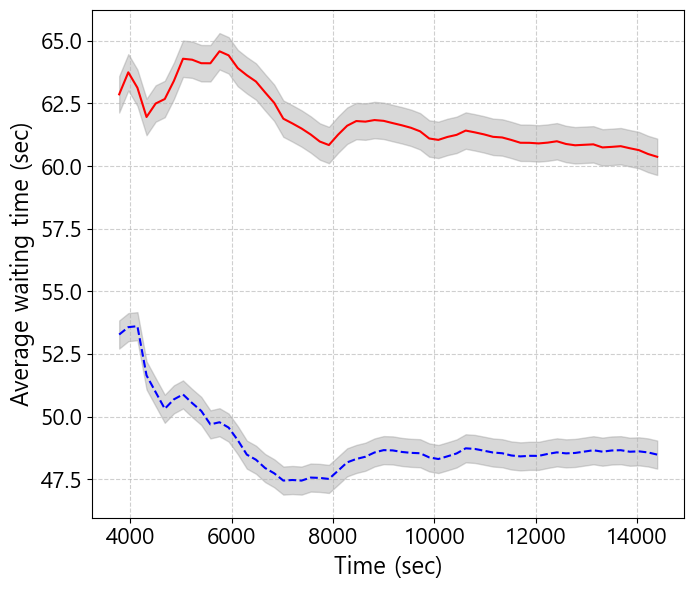

In [169]:
#############################1####################################################################################################################
# 퇴근
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rc('font', family='Malgun Gothic')

a = '출근1'
df_current = pd.read_csv('평시 신호 시뮬레이션 결과.csv')
df_pso = pd.read_csv('평시_PSO_신호 시뮬레이션 결과.csv')

current_datasets = df_current.iloc[:,1:].values.tolist()
pso_datasets = df_pso.iloc[:,1:].values.tolist()

confidence_level = 0.95
n = len(current_datasets[0])
z = 1.96

upper_combined_current = np.zeros(n)
lower_combined_current = np.zeros(n)
upper_combined_pso = np.zeros(n)
lower_combined_pso = np.zeros(n)
x_values = np.linspace(3780, 14400, n)

for i in range(n):
    means_current = [dataset[i] for dataset in current_datasets]
    std_devs_current = [np.std(dataset) for dataset in current_datasets]
    
    margin_errors_current = [z * (std_dev / np.sqrt(n)) for std_dev in std_devs_current]
    
    combined_mean_current = np.mean(means_current)
    combined_margin_error_current = np.sqrt(np.sum([error ** 2 for error in margin_errors_current]) / len(current_datasets))
    
    upper_combined_current[i] = combined_mean_current + combined_margin_error_current
    lower_combined_current[i] = combined_mean_current - combined_margin_error_current

for i in range(n):
    means_pso = [dataset[i] for dataset in pso_datasets]
    std_devs_pso = [np.std(dataset) for dataset in pso_datasets]
    
    margin_errors_pso = [z * (std_dev / np.sqrt(n)) for std_dev in std_devs_pso]
    
    # Calculate the combined confidence interval (for the mean of 'PSO' datasets)
    combined_mean_pso = np.mean(means_pso)
    combined_margin_error_pso = np.sqrt(np.sum([error ** 2 for error in margin_errors_pso]) / len(pso_datasets))
    
    upper_combined_pso[i] = combined_mean_pso + combined_margin_error_pso
    lower_combined_pso[i] = combined_mean_pso - combined_margin_error_pso

print(a)
print(f'{a} 현재', combined_mean_current)
print(f'{a} PSO', combined_mean_pso)
print(f'{a} 개선율', 100-(combined_mean_pso/combined_mean_current*100))

plt.figure(figsize=(20, 6))
plt.subplot(1,3,3)
plt.plot(np.linspace(3780, 14400, 60), [(np.mean([dataset[i] for dataset in current_datasets])) for i in range(n)], label='기존 신호', color='red')
plt.plot(np.linspace(3780, 14400, 60), [(np.mean([dataset[i] for dataset in pso_datasets])) for i in range(n)], '--', label='제안 신호', color='blue')
plt.fill_between(np.linspace(3780, 14400, 60), lower_combined_current, upper_combined_current, alpha=0.3, color='gray', label='신뢰구간 95%')
plt.fill_between(np.linspace(3780, 14400, 60), lower_combined_pso, upper_combined_pso, alpha=0.3, color='gray')

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel('Time (sec)', fontsize=17)
plt.ylabel('Average waiting time (sec)', fontsize=17)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

출근


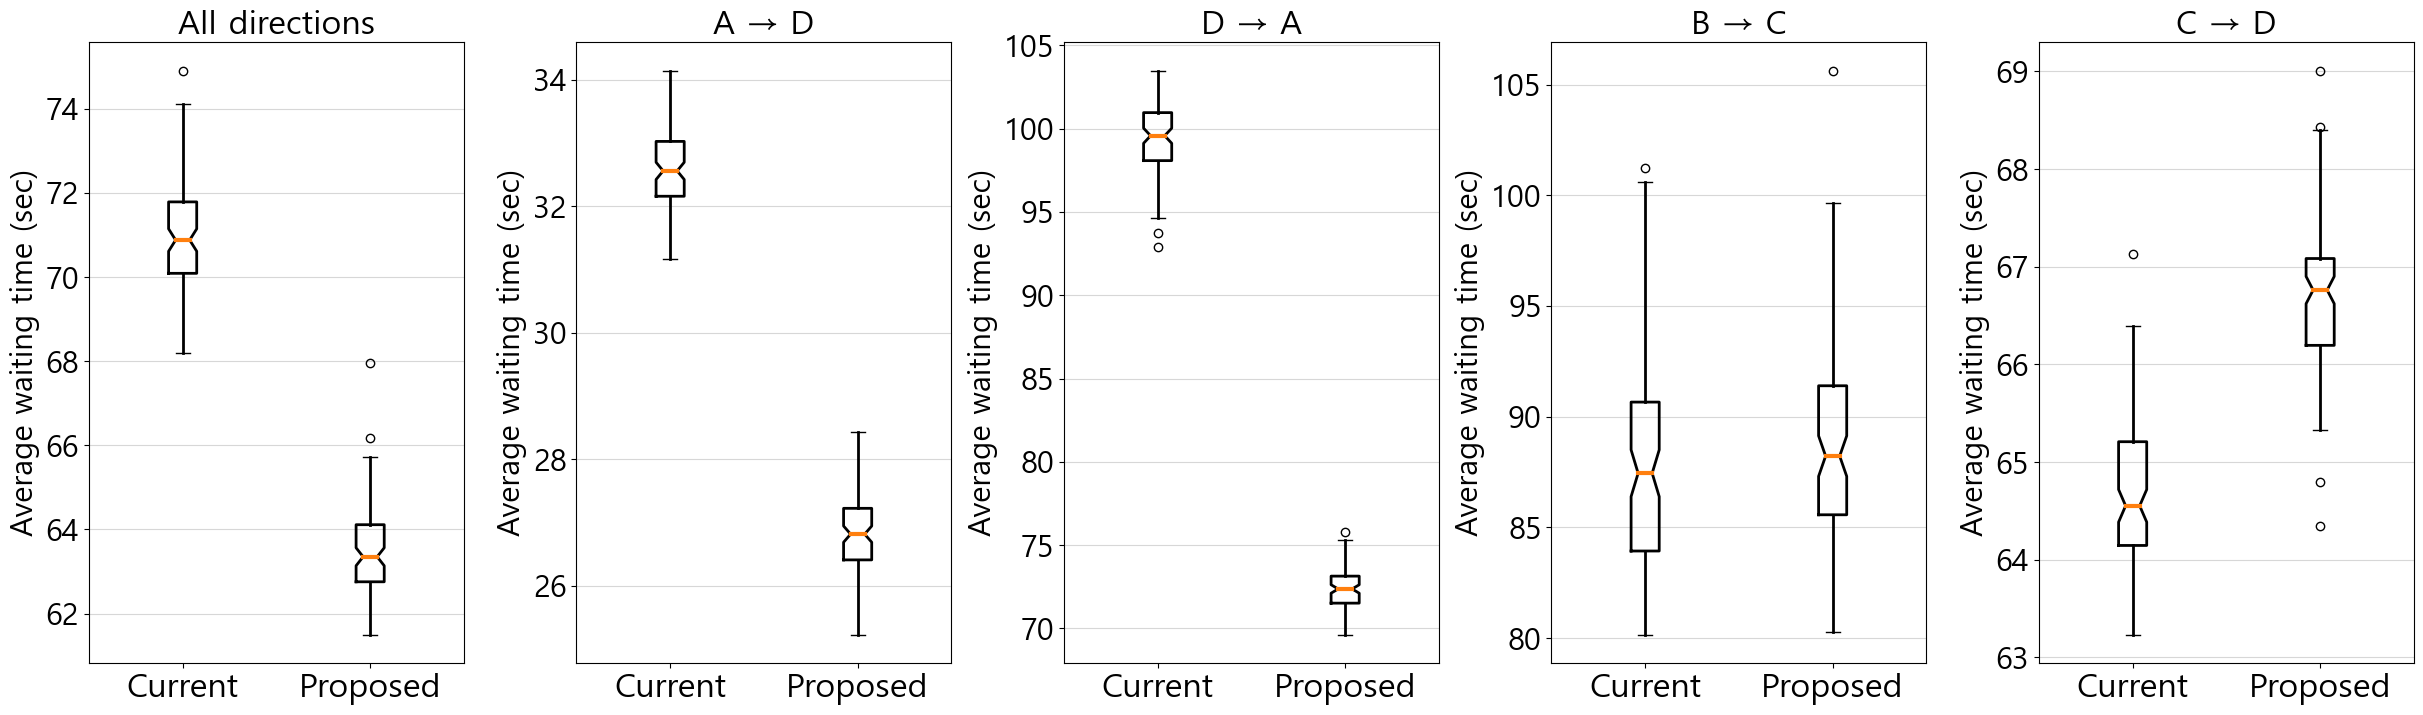

In [175]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rc('font', family='Malgun Gothic')
print('출근')
df_waiting_result = pd.read_csv('출근2_waiting_result 결과.csv')
df_waiting_result1 = pd.read_csv('출근_PSO_waiting_result 결과.csv')

df_left_right_result = pd.read_csv('출근2_left_right_result 결과.csv')
df_left_right_result1 = pd.read_csv('출근_PSO_left_right_result 결과.csv')

df_right_left_result = pd.read_csv('출근2_right_left_result 결과.csv')
df_right_left_result1 = pd.read_csv('출근_PSO_right_left_result 결과.csv')

df_up_down_result = pd.read_csv('출근2_up_down_result 결과.csv')
df_up_down_result1 = pd.read_csv('출근_PSO_up_down_result 결과.csv')

df_down_up_result = pd.read_csv('출근2_down_up_result 결과.csv')
df_down_up_result1 = pd.read_csv('출근_PSO_down_up_result 결과.csv')

waiting_result = df_waiting_result.iloc[:,1:].values.ravel().tolist()
waiting_result1 = df_waiting_result1.iloc[:,1:].values.ravel().tolist()

left_right_result = df_left_right_result.iloc[:,1:].values.ravel().tolist()
left_right_result1 = df_left_right_result1.iloc[:,1:].values.ravel().tolist()

right_left_result = df_right_left_result.iloc[:,1:].values.ravel().tolist()
right_left_result1 = df_right_left_result1.iloc[:,1:].values.ravel().tolist()

up_down_result = df_up_down_result.iloc[:,1:].values.ravel().tolist()
up_down_result1 = df_up_down_result1.iloc[:,1:].values.ravel().tolist()

down_up_result = df_down_up_result.iloc[:,1:].values.ravel().tolist()
down_up_result1 = df_down_up_result1.iloc[:,1:].values.ravel().tolist()

# Group data by categories
waiting_data = [waiting_result, waiting_result1]
left_right_data = [left_right_result, left_right_result1]
right_left_data = [right_left_result, right_left_result1]
up_down_data = [up_down_result, up_down_result1]
down_up_data = [down_up_result, down_up_result1]

data_categories = [waiting_data, left_right_data, right_left_data, up_down_data, down_up_data]
# category_names = ['모든 방향', '시화공단 → 정왕역', '정왕역 → 시화공단', '월곶 → 안산', '안산 → 월곶']
category_names = ['All directions', 'A → D', 'D → A', 'B → C', 'C → D']

# Create subplots with adjusted spacing and increased figure size
fig, axes = plt.subplots(1, 5, figsize=(30, 9), sharey=False, gridspec_kw={'wspace': 0.3})

# Define box style with wider boxes
boxprops = dict(linewidth=2)
flierprops = dict(marker='o')
whiskerprops = dict(linewidth=2)
medianprops = dict(linewidth=3)

# Plot each category in a separate subplot
for i, ax in enumerate(axes):
    boxplot = ax.boxplot(data_categories[i], boxprops=boxprops, flierprops=flierprops, notch=True, whiskerprops=whiskerprops, medianprops=medianprops)
    ax.yaxis.grid(True, alpha=0.5)
    ax.set_title(category_names[i], fontsize=24)
    ax.set_xticklabels(['Current', 'Proposed'], fontsize=24)
    ax.set_ylabel('Average waiting time (sec)', fontsize=22)
    ax.tick_params(axis='y', labelsize=22)

# Adjust the layout
plt.subplots_adjust(top=0.8)

# Show the plot
plt.show()

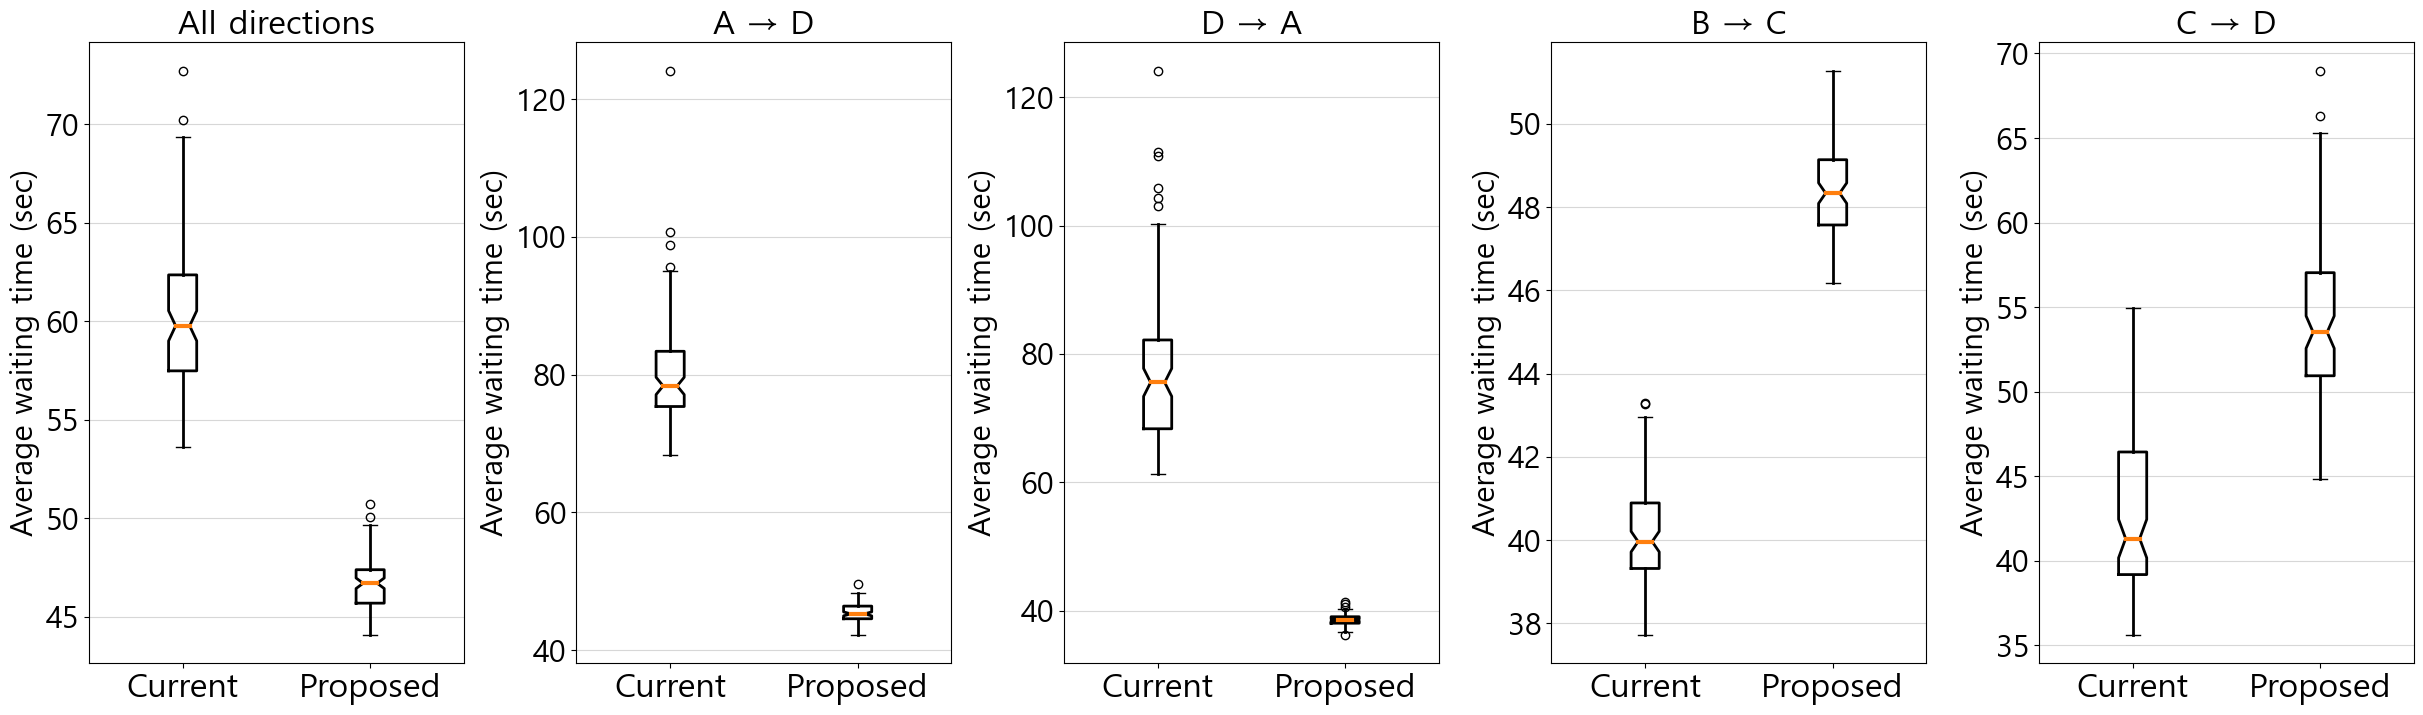

In [176]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rc('font', family='Malgun Gothic')

df_waiting_result = pd.read_csv('평시2_waiting_result 결과.csv')
df_waiting_result1 = pd.read_csv('평시1_PSO_waiting_result 결과.csv')

df_left_right_result = pd.read_csv('평시2_left_right_result 결과.csv')
df_left_right_result1 = pd.read_csv('평시1_PSO_left_right_result 결과.csv')

df_right_left_result = pd.read_csv('평시2_right_left_result 결과.csv')
df_right_left_result1 = pd.read_csv('평시1_PSO_right_left_result 결과.csv')

df_up_down_result = pd.read_csv('평시2_up_down_result 결과.csv')
df_up_down_result1 = pd.read_csv('평시1_PSO_up_down_result 결과.csv')

df_down_up_result = pd.read_csv('평시2_down_up_result 결과.csv')
df_down_up_result1 = pd.read_csv('평시1_PSO_down_up_result 결과.csv')

waiting_result = df_waiting_result.iloc[:,1:].values.ravel().tolist()
waiting_result1 = df_waiting_result1.iloc[:,1:].values.ravel().tolist()

left_right_result = df_left_right_result.iloc[:,1:].values.ravel().tolist()
left_right_result1 = df_left_right_result1.iloc[:,1:].values.ravel().tolist()

right_left_result = df_right_left_result.iloc[:,1:].values.ravel().tolist()
right_left_result1 = df_right_left_result1.iloc[:,1:].values.ravel().tolist()

up_down_result = df_up_down_result.iloc[:,1:].values.ravel().tolist()
up_down_result1 = df_up_down_result1.iloc[:,1:].values.ravel().tolist()

down_up_result = df_down_up_result.iloc[:,1:].values.ravel().tolist()
down_up_result1 = df_down_up_result1.iloc[:,1:].values.ravel().tolist()

# Group data by categories
waiting_data = [waiting_result, waiting_result1]
left_right_data = [left_right_result, left_right_result1]
right_left_data = [right_left_result, right_left_result1]
up_down_data = [up_down_result, up_down_result1]
down_up_data = [down_up_result, down_up_result1]

data_categories = [waiting_data, left_right_data, right_left_data, up_down_data, down_up_data]
#category_names = ['모든 방향', '시화공단 → 정왕역', '정왕역 → 시화공단', '월곶 → 안산', '안산 → 월곶']
category_names = ['All directions', 'A → D', 'D → A', 'B → C', 'C → D']

# Create subplots with adjusted spacing and increased figure size
fig, axes = plt.subplots(1, 5, figsize=(30, 9), sharey=False, gridspec_kw={'wspace': 0.3})

# Define box style with wider boxes
boxprops = dict(linewidth=2, color='black')
flierprops = dict(marker='o')
whiskerprops = dict(linewidth=2)
medianprops = dict(linewidth=3)

# Plot each category in a separate subplot
for i, ax in enumerate(axes):
    boxplot = ax.boxplot(data_categories[i], boxprops=boxprops, flierprops=flierprops, notch=True, whiskerprops=whiskerprops, medianprops=medianprops)
    ax.yaxis.grid(True, alpha=0.5)
    ax.set_title(category_names[i], fontsize=24)
    ax.set_xticklabels(['Current', 'Proposed'], fontsize=24) 
    ax.set_ylabel('Average waiting time (sec)', fontsize=22)
    ax.tick_params(axis='y', labelsize=22)

# Adjust the layout
plt.subplots_adjust(top=0.8)

# Show the plot
plt.show()

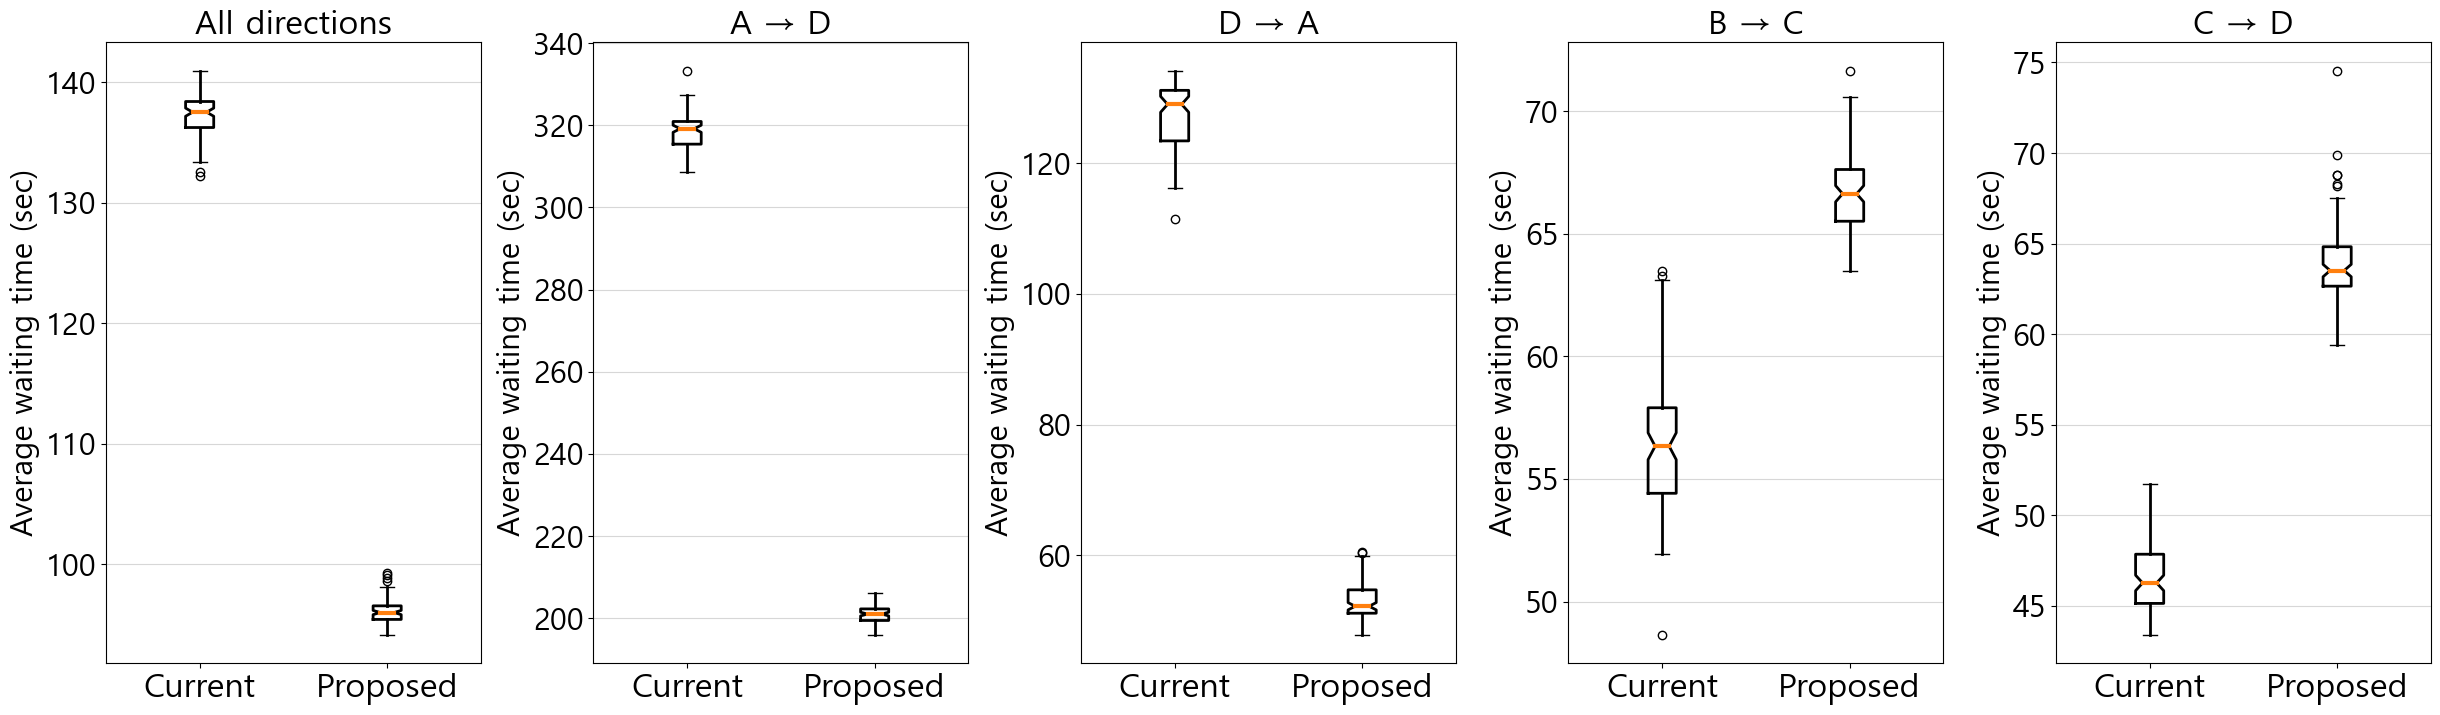

In [179]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rc('font', family='Malgun Gothic')

#df_waiting_result = pd.read_csv('./1차/퇴근_waiting_result 결과.csv')
df_waiting_result = pd.read_csv('퇴근_waiting_result 결과.csv')
df_waiting_result1 = pd.read_csv('퇴근_PSO_waiting_result 결과.csv')

#df_left_right_result = pd.read_csv('./1차/퇴근_left_right_result 결과.csv')
df_left_right_result = pd.read_csv('퇴근_left_right_result 결과.csv')
df_left_right_result1 = pd.read_csv('퇴근_PSO_left_right_result 결과.csv')

#df_right_left_result = pd.read_csv('./1차/퇴근_right_left_result 결과.csv')
df_right_left_result = pd.read_csv('퇴근_right_left_result 결과.csv')
df_right_left_result1 = pd.read_csv('퇴근_PSO_right_left_result 결과.csv')

#df_up_down_result = pd.read_csv('./1차/퇴근_up_down_result 결과.csv')
df_up_down_result1 = pd.read_csv('퇴근_up_down_result 결과.csv')
df_up_down_result1 = pd.read_csv('퇴근_PSO_up_down_result 결과.csv')

#df_down_up_result = pd.read_csv('./1차/퇴근_down_up_result 결과.csv')
df_down_up_result = pd.read_csv('퇴근_down_up_result 결과.csv')
df_down_up_result1 = pd.read_csv('퇴근_PSO_down_up_result 결과.csv')

waiting_result = df_waiting_result.iloc[:,1:].values.ravel().tolist()
waiting_result1 = df_waiting_result1.iloc[:,1:].values.ravel().tolist()

left_right_result = df_left_right_result.iloc[:,1:].values.ravel().tolist()
left_right_result1 = df_left_right_result1.iloc[:,1:].values.ravel().tolist()

right_left_result = df_right_left_result.iloc[:,1:].values.ravel().tolist()
right_left_result1 = df_right_left_result1.iloc[:,1:].values.ravel().tolist()

up_down_result = df_up_down_result.iloc[:,1:].values.ravel().tolist()
up_down_result1 = df_up_down_result1.iloc[:,1:].values.ravel().tolist()

down_up_result = df_down_up_result.iloc[:,1:].values.ravel().tolist()
down_up_result1 = df_down_up_result1.iloc[:,1:].values.ravel().tolist()

# Group data by categories
waiting_data = [waiting_result, waiting_result1]
left_right_data = [left_right_result, left_right_result1]
right_left_data = [right_left_result, right_left_result1]
up_down_data = [up_down_result, up_down_result1]
down_up_data = [down_up_result, down_up_result1]

data_categories = [waiting_data, left_right_data, right_left_data, up_down_data, down_up_data]
#category_names = ['모든 방향', '시화공단 → 정왕역', '정왕역 → 시화공단', '월곶 → 안산', '안산 → 월곶']
category_names = ['All directions', 'A → D', 'D → A', 'B → C', 'C → D']

# Create subplots with adjusted spacing and increased figure size
fig, axes = plt.subplots(1, 5, figsize=(30, 9), sharey=False, gridspec_kw={'wspace': 0.3})

# Define box style with wider boxes
boxprops = dict(linewidth=2, color='black')
flierprops = dict(marker='o')
whiskerprops = dict(linewidth=2)
medianprops = dict(linewidth=3)

# Plot each category in a separate subplot
for i, ax in enumerate(axes):
    boxplot = ax.boxplot(data_categories[i], boxprops=boxprops, flierprops=flierprops, notch=True, whiskerprops=whiskerprops, medianprops=medianprops)
    ax.yaxis.grid(True, alpha=0.5)
    ax.set_title(category_names[i], fontsize=24)
    ax.set_xticklabels(['Current', 'Proposed'], fontsize=24) 
    ax.set_ylabel('Average waiting time (sec)', fontsize=22)
    ax.tick_params(axis='y', labelsize=22)

# Adjust the layout
plt.subplots_adjust(top=0.8)

# Show the plot
plt.show()